In [1]:
!pip install pyspark==4.1.1 findspark pandas matplotlib 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 18.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 24.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 26.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 21.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 24.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.0/203.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 8.0 MB/s eta 

# Analisis de Planes de Ejecucion en Apache Spark

## Que es el Execution Plan?

El **Execution Plan** es el "mapa de ruta" que crea Spark para transformar tus transformaciones de alto nivel (como `.select()` o `.join()`) en tareas fisicas ejecutables en un cluster.

Spark utiliza un optimizador llamado **Catalyst**, que procesa la consulta en 4 fases:

```
 Tu codigo (DataFrame / SQL)
        |
        v
 1. Unresolved Logical Plan   -->  Verifica solo la sintaxis
        |
        v
 2. Resolved Logical Plan      -->  Valida columnas y tipos contra el catalogo (metastore)
        |
        v
 3. Optimized Logical Plan     -->  Aplica reglas de optimizacion:
        |                            - Predicate Pushdown (filtrar lo antes posible)
        |                            - Column Pruning (leer solo columnas necesarias)
        |                            - Constant Folding (precalcular expresiones constantes)
        v
 4. Physical Plan              -->  Elige la estrategia real de ejecucion:
                                     - SortMergeJoin o BroadcastJoin?
                                     - HashAggregate o SortAggregate?
                                     - AQE ajusta el plan en runtime (Spark 3.2+)
```

### Modos de `explain()`

| Modo | Descripcion |
|---|---|
| `df.explain()` | Solo muestra el Physical Plan |
| `df.explain(True)` | Muestra los 4 planes (Parsed, Analyzed, Optimized, Physical) |
| `df.explain(mode="formatted")` | Physical Plan con formato legible y detallado (el que usamos aqui) |
| `df.explain(mode="cost")` | Incluye estadisticas de coste estimado |
| `df.explain(mode="codegen")` | Muestra el codigo Java generado por Whole-Stage CodeGen |

## Guia rapida para interpretar los Planes

Al revisar el output de `explain()`, busca estas palabras clave:

| Palabra clave | Que significa | Ejemplo en el plan |
|---|---|---|
| `PushedFilters` | El filtro se envio al nivel de lectura (I/O). En Parquet es mas eficiente que en CSV porque es columnar. | `PushedFilters: [IsNotNull(id_region), EqualTo(id_region,5)]` |
| `PartitionFilters` | Spark **ignora carpetas enteras** que no cumplen la condicion. Solo lee las particiones necesarias. | `PartitionFilters: [id_region = 5]` |
| `Exchange` | **Shuffle** — los datos se redistribuyen por la red entre nodos. Es la operacion mas costosa. | `Exchange hashpartitioning(id_region, 200)` |
| `Sort` | Ordenacion de datos, generalmente previa a un `SortMergeJoin` o `Window`. | `Sort [id ASC NULLS FIRST]` |
| `BroadcastExchange` | La tabla pequena se envia completa a todos los nodos. Mucho mejor que un Shuffle. | `BroadcastExchange HashedRelationBroadcastMode` |
| `Bucketed: true` | Los datos ya estan pre-particionados en disco, evitando el Shuffle en joins. | `Bucketed: true, SelectedBucketsCount: 10 out of 10` |
| `AdaptiveSparkPlan` | AQE esta activo. El plan puede cambiar en runtime segun las estadisticas reales. | `isFinalPlan=false` (aun no ejecutado) |
| `*` (asterisco) | Indica **Whole-Stage CodeGen**: Spark genera codigo Java optimizado para esos operadores. | `* Filter (2)` vs `Filter (2)` |

> **Regla de oro:** Cuantos menos `Exchange` (Shuffles) tenga tu plan, mas eficiente sera tu consulta.

In [8]:
# Borramos los datos de ejecuciones anteriores
!rm -rf ./data_*
!rm -rf ./data.*
!rm -rf ./spark-*

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, rand, count, sum, expr
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import shutil
import findspark

findspark.init()

# Configuración de Spark 4.1.0 con AQE habilitado
# Desactivamos las optimizaciones solo para mostrar los resultados no hacer en producción
spark = (SparkSession.builder
    .appName("Spark4_ExecutionPlan_Analysis")
    .config("spark.sql.adaptive.enabled", "false")
    .config("spark.sql.autoBroadcastJoinThreshold", "-1")
    .config("spark.driver.memory","10G")
    .master("local[4]")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")

print(f"Versión de Spark: {spark.version}")

Versión de Spark: 4.1.1


El Catalyst Optimizer (reglas como predicate pushdown, constant folding, column pruning) no se puede desactivar completamente con una sola propiedad. 

Son reglas internas del motor. Sin embargo, puedes desactivar reglas específicas:

In [12]:
# Cambiar el número de particiones para todas las operaciones de Shuffle (Join, GroupBy)
# Este valor es numero de CPU por Executor --> .master("local[4]")
spark.conf.set("spark.sql.shuffle.partitions", "10")

In [13]:
spark.conf.set("spark.sql.adaptive.enabled", "false")      # Desactiva AQE (coalesce dinámico, skew join, etc.) │
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1) # Con -1 evita broadcast joins automáticos           │
spark.conf.set("spark.sql.cbo.enabled", "false")           # Desactiva el optimizador basado en costes
spark.conf.set("spark.sql.exchange.reuse", "false")        # Desactiva reutilización de shuffles
spark.conf.set("spark.sql.subquery.reuse", "false")        # Desactiva reutilización de subqueries 

In [37]:
# Desactiva predicate pushdown (solo para fuentes de datos)
#spark.conf.set("spark.sql.parquet.filterPushdown", "false")
#spark.conf.set("spark.sql.orc.filterPushdown", "false")

# Desactiva column pruning en fuentes
#spark.conf.set("spark.sql.parquet.enableNestedColumnVectorizedReader", "false")


---

## 1. Configuracion y Generacion de Datos

Generamos un dataset de **1 millon de registros** simulando ventas, y lo guardamos en 4 formatos distintos para comparar como afecta la estructura de almacenamiento al plan de ejecucion:

| Formato | Archivo | Caracteristica clave |
|---|---|---|
| **CSV** | `data.csv` | Formato texto, sin optimizaciones de lectura |
| **Parquet simple** | `data_raw.parquet` | Columnar, permite Column Pruning y PushedFilters |
| **Parquet particionado** | `data_part.parquet/` | Directorios por `id_region`, permite Partition Pruning |
| **Parquet bucketizado** | `ventas_bucket` (tabla Spark) | Pre-distribuido por `id_producto` en 10 buckets, evita Shuffles en joins |

> **Nota sobre la configuracion:** Desactivamos `autoBroadcastJoinThreshold` (valor `-1`) para forzar `SortMergeJoin` en los ejemplos de Join y poder comparar estrategias manualmente.

In [14]:
# Crear un dataset base de 1 millón de registros
df_base = spark.range(0, 10_000_000).select(
    col("id"),
    (rand() * 100).cast("int").alias("id_producto"),
    (rand() * 1000).alias("monto"),
    (rand() * 10).cast("int").alias("id_region")
)

In [15]:
# 1. Parquet simple (sin particionar)
df_base.write.mode("overwrite").parquet("data_raw.parquet")

In [16]:
# 2. Parquet particionado por región
df_base.write.mode("overwrite").partitionBy("id_region").parquet("data_part.parquet")

In [17]:
spark.sql("DROP TABLE IF EXISTS ventas_bucket")

DataFrame[]

In [20]:
# 3. Parquet bucketizado (usando tablas de Spark)
df_base.write.format("parquet") \
    .mode("overwrite") \
    .partitionBy('id_region') \ 
    .bucketBy(10, "id_producto") \
    .sortBy("id_producto") \
    .saveAsTable("ventas_bucket")

In [21]:
# 4. CSV para probar Filter Pushdown
df_base.write.mode("overwrite").option("header", "true").csv("data.csv")

In [47]:
df_base.show(truncate=False)

+---+-----------+------------------+---------+
|id |id_producto|monto             |id_region|
+---+-----------+------------------+---------+
|0  |17         |777.9781294103681 |8        |
|1  |52         |927.6856964484864 |3        |
|2  |3          |332.4599430470475 |0        |
|3  |92         |389.79446850174526|4        |
|4  |54         |752.2491435741027 |4        |
|5  |45         |973.9204359811691 |0        |
|6  |60         |430.4353507552321 |1        |
|7  |89         |640.1017095090065 |1        |
|8  |63         |693.8070314814238 |1        |
|9  |84         |860.1896024817826 |8        |
|10 |8          |575.3464947300646 |7        |
|11 |24         |779.4429442406163 |3        |
|12 |96         |654.8231512546963 |0        |
|13 |19         |742.3067698153602 |0        |
|14 |80         |3.681419538236086 |7        |
|15 |82         |942.3313627115455 |4        |
|16 |39         |378.9031362165741 |3        |
|17 |2          |988.1670308939744 |0        |
|18 |12      

## 2. Funcion de analisis y benchmark

La funcion `analyze_and_run()` hace tres cosas para cada consulta:
1. **`df.explain(mode="formatted")`** — Muestra el Physical Plan detallado (sin ejecutar la consulta).
2. **`df.count()`** — Fuerza la ejecucion real (las transformaciones en Spark son *lazy*).
3. **Mide el tiempo** — Registra cuanto tardo la ejecucion para comparar despues en el grafico.

> **Recuerda:** `explain()` solo muestra el plan, no ejecuta nada. Necesitamos una **accion** (`count`, `show`, `collect`, `write`) para que Spark realmente procese los datos.

In [23]:
results = []

def analyze_and_run(df, title):
    print(f"\n{'='*20} {title} {'='*20}")
    
    # Capturamos el inicio
    start = time.time()
    
    # Explicación del plan
    # El método explain(True) muestra: Logical, Analyzed, Optimized y Physical Plan
    df.explain(mode="formatted") 
    
    # Ejecutamos una acción para activar el cálculo
    count_res = df.count()
    
    end = time.time()
    duration = end - start
    results.append({"Escenario": title, "Tiempo": duration})
    print(f"Tiempo de ejecución: {duration:.4f} segundos")
    return df

---

## 3. Lectura y Filtrado: Filter Pushdown vs Partition Pruning

Comparamos como Spark maneja el filtrado segun el formato de almacenamiento.

### Caso 1: Filter Pushdown en CSV

Cuando filtramos sobre un CSV, Spark **debe leer todo el archivo** linea por linea y luego filtrar. El CSV no tiene metadatos de columnas ni estadisticas, asi que:
- `PushedFilters: [IsNotNull(id_region)]` — Solo puede empujar el filtro de nulidad, no el valor exacto.
- `Batched: false` — No puede leer en lotes optimizados.
- Todas las columnas se leen como `string` (observa el `ReadSchema`).
- El filtro real (`id_region = 5`) se aplica **despues** de leer, en el nodo `Filter`.

```
Scan csv (lee TODO el archivo) --> Filter (filtra en memoria)
```

In [49]:
# CASO 1: Filter Pushdown en CSV (Menos eficiente)
df_csv = spark.read.option("header", "true").csv("data.csv")
df_csv_plan = analyze_and_run(df_csv.filter(col("id_region") == 5), "Filter Pushdown (CSV)")


==================== Filter Pushdown (CSV) ====================
== Physical Plan ==
* Filter (2)
+- Scan csv  (1)


(1) Scan csv 
Output [4]: [id#618, id_producto#619, monto#620, id_region#621]
Batched: false
Location: InMemoryFileIndex [file:/home/jovyan/work/data.csv]
PushedFilters: [IsNotNull(id_region)]
ReadSchema: struct<id:string,id_producto:string,monto:string,id_region:string>

(2) Filter [codegen id : 1]
Input [4]: [id#618, id_producto#619, monto#620, id_region#621]
Condition : (isnotnull(id_region#621) AND (cast(id_region#621 as bigint) = 5))




Tiempo de ejecución: 1.7135 segundos


In [14]:
df_csv_plan.explain(mode="codegen")

Found 1 WholeStageCodegen subtrees.
== Subtree 1 / 1 (maxMethodCodeSize:381; maxConstantPoolSize:129(0.20% used); numInnerClasses:0) ==
*(1) Filter (isnotnull(id_region#37) AND (cast(id_region#37 as bigint) = 5))
+- FileScan csv [id#34,id_producto#35,monto#36,id_region#37] Batched: false, DataFilters: [isnotnull(id_region#37), (cast(id_region#37 as bigint) = 5)], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/home/jovyan/work/data.csv], PartitionFilters: [], PushedFilters: [IsNotNull(id_region)], ReadSchema: struct<id:string,id_producto:string,monto:string,id_region:string>

Generated code:
/* 001 */ public Object generate(Object[] references) {
/* 002 */   return new GeneratedIteratorForCodegenStage1(references);
/* 003 */ }
/* 004 */
/* 005 */ // codegenStageId=1
/* 006 */ final class GeneratedIteratorForCodegenStage1 extends org.apache.spark.sql.execution.BufferedRowIterator {
/* 007 */   private Object[] references;
/* 008 */   private scala.collection.Iterator[] inputs;
/

### Caso 2: Partition Pruning en Parquet particionado

Cuando los datos estan **particionados** por una columna (en este caso `id_region`), Spark organiza los archivos en directorios:
```
data_part.parquet/
  id_region=0/  part-00000.parquet
  id_region=1/  part-00000.parquet
  ...
  id_region=9/  part-00000.parquet
```

Al filtrar por `id_region = 5`, Spark **ni siquiera abre** los directorios de las otras regiones. Esto se llama **Partition Pruning**.

**En el plan veras:**
- `PartitionFilters: [id_region = 5]` — El filtro se aplica a nivel de directorio, no de fila.
- **No hay nodo `Filter`** separado — el filtrado ocurre en el propio `Scan`.
- `Batched: true` — Parquet permite lectura vectorizada (mucho mas rapido).
- `ReadSchema` NO incluye `id_region` — la columna de particion se infiere del nombre del directorio.

```
Scan parquet (solo lee la carpeta id_region=5) --> ColumnarToRow
```

In [15]:
# CASO 2: Partition Pruning en Parquet (Muy eficiente)
df_part = spark.read.parquet("data_part.parquet")
analyze_and_run(df_part.filter(col("id_region") == 5), "Partition Pruning (Parquet)")


==================== Partition Pruning (Parquet) ====================
== Physical Plan ==
* ColumnarToRow (2)
+- Scan parquet  (1)


(1) Scan parquet 
Output [4]: [id#48L, id_producto#49, monto#50, id_region#51]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_part.parquet]
PartitionFilters: [isnotnull(id_region#51), (id_region#51 = 5)]
ReadSchema: struct<id:bigint,id_producto:int,monto:double>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [id#48L, id_producto#49, monto#50, id_region#51]


Tiempo de ejecución: 0.1302 segundos


DataFrame[id: bigint, id_producto: int, monto: double, id_region: int]

---

### Caso 3: Group By con Shuffle

Un `GROUP BY` requiere que todas las filas con la misma clave esten en la **misma particion**. Como los datos en `data_raw.parquet` no estan organizados por `id_region`, Spark necesita un **Shuffle** (redistribucion por red).

**En el plan veras el patron clasico de agregacion en 2 fases:**

```
Scan parquet
    |
    v
HashAggregate (parcial)    <-- Cada particion agrega localmente (reduce datos antes del shuffle)
    |
    v
Exchange hashpartitioning  <-- SHUFFLE: redistribuye por id_region (200 particiones por defecto)
    |
    v
HashAggregate (final)      <-- Agrega los resultados parciales ya agrupados
    |
    v
AdaptiveSparkPlan          <-- AQE puede reducir las 200 particiones si muchas estan vacias
```

**Por que dos HashAggregate?** Es una optimizacion: el primero reduce los datos **antes** del Shuffle (pre-agregacion local), minimizando el trafico de red. Sin esta optimizacion, se moverian 1M de filas por red en lugar de solo los parciales.

In [24]:
# CASO 3: Group By con Shuffle (Sin bucketizar)
df_raw = spark.read.parquet("data_raw.parquet")
query_agg = df_raw.groupBy("id_region").agg(sum("monto"))
analyze_and_run(query_agg, "Group By (Sin Bucket)")


==================== Group By (Sin Bucket) ====================
== Physical Plan ==
* HashAggregate (5)
+- Exchange (4)
   +- * HashAggregate (3)
      +- * ColumnarToRow (2)
         +- Scan parquet  (1)


(1) Scan parquet 
Output [2]: [monto#10, id_region#11]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [2]: [monto#10, id_region#11]

(3) HashAggregate [codegen id : 1]
Input [2]: [monto#10, id_region#11]
Keys [1]: [id_region#11]
Functions [1]: [partial_sum(monto#10)]
Aggregate Attributes [1]: [sum#19]
Results [2]: [id_region#11, sum#20]

(4) Exchange
Input [2]: [id_region#11, sum#20]
Arguments: hashpartitioning(id_region#11, 10), ENSURE_REQUIREMENTS, [plan_id=116]

(5) HashAggregate [codegen id : 2]
Input [2]: [id_region#11, sum#20]
Keys [1]: [id_region#11]
Functions [1]: [sum(monto#10)]
Aggregate Attributes [1]: [sum(monto#10)#16]
Results [2]: [id_region#11

Tiempo de ejecución: 1.7877 segundos


DataFrame[id_region: int, sum(monto): double]

---

### Caso 4: Join con Bucketing (eliminando Shuffles)

El **Bucketing** pre-distribuye los datos en disco por una columna clave. Si dos tablas estan bucketizadas por la **misma columna** y el **mismo numero de buckets**, Spark puede hacer el Join **sin Shuffle** porque los datos ya estan co-localizados.

**En el plan, busca estas diferencias respecto a un Join normal:**
- `Bucketed: true` + `SelectedBucketsCount: 10 out of 10` — Spark reconoce el bucketing.
- **Sin `Exchange`** en el lado bucketizado — No necesita Shuffle.
- `SortMergeJoin` sin `Exchange` previo = Join sin movimiento de datos por red.

> **Atencion:** Si Spark muestra `Bucketed: false (disabled by query planner)`, significa que AQE decidio que el bucketing no es beneficioso para esta consulta concreta (por ejemplo, si los tipos de la columna de join no coinciden exactamente entre ambas tablas).

In [25]:
# CASO 4: Join Optimizado con Bucket
# Creamos una tabla pequeña de productos también bucketizada
df_prod = spark.range(0, 100).select(col("id").alias("id_producto"), (rand()*10).alias("stock"))
df_prod.write.format("parquet").bucketBy(10, "id_producto").saveAsTable("prod_bucket")

df_v_bucket = spark.table("ventas_bucket")
df_p_bucket = spark.table("prod_bucket")
join_query = df_v_bucket.join(df_p_bucket, "id_producto")

analyze_and_run(join_query, "Join con Bucket (No Shuffle)")


==================== Join con Bucket (No Shuffle) ====================
== Physical Plan ==
* Project (11)
+- * SortMergeJoin Inner (10)
   :- * Sort (5)
   :  +- Exchange (4)
   :     +- * Filter (3)
   :        +- * ColumnarToRow (2)
   :           +- Scan parquet spark_catalog.default.ventas_bucket (1)
   +- * Sort (9)
      +- * Filter (8)
         +- * ColumnarToRow (7)
            +- Scan parquet spark_catalog.default.prod_bucket (6)


(1) Scan parquet spark_catalog.default.ventas_bucket
Output [4]: [id#30L, id_producto#31, monto#32, id_region#33]
Batched: true
Bucketed: false (disabled by query planner)
Location: CatalogFileIndex [file:/home/jovyan/work/spark-warehouse/ventas_bucket]
PushedFilters: [IsNotNull(id_producto)]
ReadSchema: struct<id:bigint,id_producto:int,monto:double>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [id#30L, id_producto#31, monto#32, id_region#33]

(3) Filter [codegen id : 1]
Input [4]: [id#30L, id_producto#31, monto#32, id_region#33]
Condition : isno

Tiempo de ejecución: 24.0355 segundos


DataFrame[id_producto: int, id: bigint, monto: double, id_region: int, stock: double]

---

## 4. Operaciones Avanzadas de Agregacion

### Caso 5: ROLLUP — Subtotales jerarquicos

`ROLLUP` genera subtotales **jerarquicos**. Dado un `ROLLUP(A, B)`, produce estos niveles de agrupacion:

| Nivel | Agrupacion | Significado |
|---|---|---|
| 1 | `(A, B)` | Detalle completo |
| 2 | `(A)` | Subtotal por A (B es `null`) |
| 3 | `()` | Gran total (ambos son `null`) |

**En el plan de ejecucion veras:**

```
Scan parquet
    |
    v
Expand           <-- Replica cada fila 3 veces (una por nivel de agrupacion)
    |
    v
HashAggregate    <-- Agregacion parcial (local)
    |
    v
Exchange         <-- Shuffle por las claves de agrupacion
    |
    v
HashAggregate    <-- Agregacion final
```

> **El operador `Expand` es la clave:** multiplica las filas. Para `ROLLUP(A, B)` genera 3 copias de cada fila (n+1). Con 1M de filas, Expand produce 3M de filas internas antes de agregar.

In [18]:
# CASO 5: ROLLUP - Subtotales jerárquicos
df_raw = spark.read.parquet("data_raw.parquet")

# ROLLUP genera subtotales: (region, producto), (region), (total)
query_rollup = df_raw.rollup("id_region", "id_producto").agg(
    sum("monto").alias("total_monto"),
    count("*").alias("num_ventas")
)

print("=== CASO 5: ROLLUP ===")
print("Genera subtotales jerárquicos: (region, producto), (region), (gran total)")
print()
query_rollup.explain(mode="formatted")

# Mostramos algunos resultados para entender la salida
print("\n--- Ejemplo de filas con ROLLUP (nulls = subtotales) ---")
query_rollup.orderBy("id_region", "id_producto").show(15, truncate=False)

analyze_and_run(query_rollup, "ROLLUP (región, producto)")

=== CASO 5: ROLLUP ===
Genera subtotales jerárquicos: (region, producto), (region), (gran total)

== Physical Plan ==
* HashAggregate (6)
+- Exchange (5)
   +- * HashAggregate (4)
      +- * Expand (3)
         +- * ColumnarToRow (2)
            +- Scan parquet  (1)


(1) Scan parquet 
Output [3]: [id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [3]: [id_producto#101, monto#102, id_region#103]

(3) Expand [codegen id : 1]
Input [3]: [id_producto#101, monto#102, id_region#103]
Arguments: [[monto#102, id_region#103, id_producto#101, 0], [monto#102, id_region#103, null, 1], [monto#102, null, null, 3]], [monto#102, id_region#115, id_producto#116, spark_grouping_id#114L]

(4) HashAggregate [codegen id : 1]
Input [4]: [monto#102, id_region#115, id_producto#116, spark_grouping_id#114L]
Keys [3]: [id_region#115, 

DataFrame[id_region: int, id_producto: int, total_monto: double, num_ventas: bigint]

### Caso 6: CUBE — Todas las combinaciones

`CUBE` genera **todas** las combinaciones posibles de agrupacion. Dado un `CUBE(A, B)`, produce:

| Nivel | Agrupacion | Significado |
|---|---|---|
| 1 | `(A, B)` | Detalle completo |
| 2 | `(A)` | Subtotal por A |
| 3 | `(B)` | Subtotal por B |
| 4 | `()` | Gran total |

**Diferencia clave con ROLLUP:**

| | ROLLUP(A, B) | CUBE(A, B) |
|---|---|---|
| Combinaciones | n+1 = **3** | 2^n = **4** |
| Incluye `(B)` solo? | No | **Si** |
| Coste del Expand | Menor | **Mayor** |

**En el plan:** Mismo patron `Expand -> HashAggregate -> Exchange -> HashAggregate`, pero el `Expand` genera **4 copias** de cada fila (2^n) en lugar de 3 (n+1). Con 1M de filas, CUBE produce 4M de filas internas.

In [19]:
# CASO 6: CUBE - Todas las combinaciones de agrupación
query_cube = df_raw.cube("id_region", "id_producto").agg(
    sum("monto").alias("total_monto"),
    count("*").alias("num_ventas")
)

print("=== CASO 6: CUBE ===")
print("Genera TODAS las combinaciones: (region, producto), (region), (producto), (total)")
print()
query_cube.explain(mode="formatted")

# Filas donde id_region es null = subtotal solo por producto
# Filas donde id_producto es null = subtotal solo por region
# Filas donde ambos son null = gran total
print("\n--- Ejemplo: subtotales por producto (id_region=null) ---")
query_cube.filter(col("id_region").isNull() & col("id_producto").isNotNull()) \
    .orderBy("id_producto").show(10, truncate=False)

analyze_and_run(query_cube, "CUBE (región, producto)")

=== CASO 6: CUBE ===
Genera TODAS las combinaciones: (region, producto), (region), (producto), (total)

== Physical Plan ==
* HashAggregate (6)
+- Exchange (5)
   +- * HashAggregate (4)
      +- * Expand (3)
         +- * ColumnarToRow (2)
            +- Scan parquet  (1)


(1) Scan parquet 
Output [3]: [id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [3]: [id_producto#101, monto#102, id_region#103]

(3) Expand [codegen id : 1]
Input [3]: [id_producto#101, monto#102, id_region#103]
Arguments: [[monto#102, id_region#103, id_producto#101, 0], [monto#102, id_region#103, null, 1], [monto#102, null, id_producto#101, 2], [monto#102, null, null, 3]], [monto#102, id_region#154, id_producto#155, spark_grouping_id#153L]

(4) HashAggregate [codegen id : 1]
Input [4]: [monto#102, id_region#154, id_producto#155, spark

DataFrame[id_region: int, id_producto: int, total_monto: double, num_ventas: bigint]

---

## 5. Window Functions (Funciones de Ventana)

Las funciones de ventana permiten hacer calculos sobre un "marco" de filas relacionadas **sin colapsar** las filas como hace `GROUP BY`. Son fundamentales para:

| Tipo | Funciones | Uso tipico |
|---|---|---|
| **Ranking** | `ROW_NUMBER`, `RANK`, `DENSE_RANK`, `NTILE` | Numerar, rankear, asignar percentiles |
| **Navegacion** | `LAG`, `LEAD`, `FIRST_VALUE`, `LAST_VALUE` | Acceder a filas vecinas |
| **Agregacion** | `SUM`, `AVG`, `COUNT`, `MIN`, `MAX` con `OVER` | Totales acumulados, medias moviles |

**En el plan de ejecucion veras:**

```
Scan parquet
    |
    v
Exchange hashpartitioning(partition_col)   <-- Shuffle por PARTITION BY
    |
    v
Sort [partition_col, order_col]            <-- Ordena dentro de cada particion
    |
    v
Window [funcion OVER ...]                  <-- Evalua la funcion de ventana
```

**Optimizacion clave:** Si tienes varias funciones de ventana con la **misma** `PARTITION BY` y `ORDER BY`, Spark las combina en un **unico operador Window** (un solo Shuffle + Sort). Si tienen distinto `PARTITION BY`, necesita Shuffles separados.

In [20]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, rank, dense_rank, lag, lead, avg

# CASO 7a: Window Functions - Mismo PARTITION BY (se combinan en un solo Window)
print("=== CASO 7a: Window Functions con misma partición (optimizado) ===")
print("ROW_NUMBER, RANK y SUM acumulado sobre la MISMA ventana")
print()

w = Window.partitionBy("id_region").orderBy("monto")

query_window_same = df_raw.select(
    "id", "id_region", "id_producto", "monto",
    row_number().over(w).alias("row_num"),
    rank().over(w).alias("ranking"),
    sum("monto").over(w).alias("monto_acumulado")
)

query_window_same.explain(mode="formatted")
print("\n--- Resultado (primeras filas de región 0) ---")
query_window_same.filter(col("id_region") == 0).show(10, truncate=False)

analyze_and_run(query_window_same, "Window (misma partición)")

=== CASO 7a: Window Functions con misma partición (optimizado) ===
ROW_NUMBER, RANK y SUM acumulado sobre la MISMA ventana

== Physical Plan ==
Window (6)
+- * Sort (5)
   +- Exchange (4)
      +- * Project (3)
         +- * ColumnarToRow (2)
            +- Scan parquet  (1)


(1) Scan parquet 
Output [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<id:bigint,id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(3) Project [codegen id : 1]
Output [4]: [id#100L, id_region#103, id_producto#101, monto#102]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(4) Exchange
Input [4]: [id#100L, id_region#103, id_producto#101, monto#102]
Arguments: hashpartitioning(id_region#103, 10), ENSURE_REQUIREMENTS, [plan_id=740]

(5) Sort [codegen id : 2]
Input [4]: [id#100L, id_region#103,

+-------+---------+-----------+---------------------+-------+-------+---------------------+
|id     |id_region|id_producto|monto                |row_num|ranking|monto_acumulado      |
+-------+---------+-----------+---------------------+-------+-------+---------------------+
|9276561|0        |40         |0.0011378926806360212|1      |1      |0.0011378926806360212|
|5983734|0        |21         |0.0012742366248819081|2      |2      |0.0024121293055179294|
|3970622|0        |11         |0.0027773370134820397|3      |3      |0.005189466318999969 |
|4276890|0        |69         |0.0034104125601341906|4      |4      |0.00859987887913416  |
|2208844|0        |16         |0.003920484455077755 |5      |5      |0.012520363334211915 |
|7506537|0        |90         |0.004019455729364907 |6      |6      |0.01653981906357682  |
|1112170|0        |39         |0.004741646074446493 |7      |7      |0.021281465138023314 |
|6312860|0        |72         |0.005306516960512653 |8      |8      |0.026587982

DataFrame[id: bigint, id_region: int, id_producto: int, monto: double, row_num: int, ranking: int, monto_acumulado: double]

In [21]:
# CASO 7b: Window Functions - Distinto PARTITION BY (genera Shuffles adicionales)
print("=== CASO 7b: Window Functions con DISTINTA partición ===")
print("Fíjate cómo aparecen DOS Exchange (Shuffle) porque cada ventana tiene distinto PARTITION BY")
print()

w_region = Window.partitionBy("id_region").orderBy("monto")
w_producto = Window.partitionBy("id_producto").orderBy("monto")

query_window_diff = df_raw.select(
    "id", "id_region", "id_producto", "monto",
    row_number().over(w_region).alias("rank_en_region"),
    row_number().over(w_producto).alias("rank_en_producto")
)

query_window_diff.explain(mode="formatted")

analyze_and_run(query_window_diff, "Window (distinta partición)")

=== CASO 7b: Window Functions con DISTINTA partición ===
Fíjate cómo aparecen DOS Exchange (Shuffle) porque cada ventana tiene distinto PARTITION BY

== Physical Plan ==
Window (9)
+- * Sort (8)
   +- Exchange (7)
      +- Window (6)
         +- * Sort (5)
            +- Exchange (4)
               +- * Project (3)
                  +- * ColumnarToRow (2)
                     +- Scan parquet  (1)


(1) Scan parquet 
Output [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<id:bigint,id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(3) Project [codegen id : 1]
Output [4]: [id#100L, id_region#103, id_producto#101, monto#102]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(4) Exchange
Input [4]: [id#100L, id_region#103, id_producto#101, monto#102]
Arguments: hashpartit

DataFrame[id: bigint, id_region: int, id_producto: int, monto: double, rank_en_region: int, rank_en_producto: int]

In [22]:
# CASO 7c: LAG y LEAD - Acceso a filas anteriores y siguientes
print("=== CASO 7c: LAG y LEAD ===")
print("Acceso a la fila anterior y siguiente dentro de cada partición")
print()

w_lag = Window.partitionBy("id_region").orderBy("id")

query_lag_lead = df_raw.select(
    "id", "id_region", "monto",
    lag("monto", 1).over(w_lag).alias("monto_anterior"),
    lead("monto", 1).over(w_lag).alias("monto_siguiente"),
    (col("monto") - lag("monto", 1).over(w_lag)).alias("diferencia_con_anterior")
)

query_lag_lead.explain(mode="formatted")
print("\n--- Resultado (primeras filas de región 0) ---")
query_lag_lead.filter(col("id_region") == 0).show(10, truncate=False)

analyze_and_run(query_lag_lead, "LAG/LEAD")

=== CASO 7c: LAG y LEAD ===
Acceso a la fila anterior y siguiente dentro de cada partición

== Physical Plan ==
* Project (6)
+- Window (5)
   +- * Sort (4)
      +- Exchange (3)
         +- * ColumnarToRow (2)
            +- Scan parquet  (1)


(1) Scan parquet 
Output [3]: [id#100L, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<id:bigint,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [3]: [id#100L, monto#102, id_region#103]

(3) Exchange
Input [3]: [id#100L, monto#102, id_region#103]
Arguments: hashpartitioning(id_region#103, 10), ENSURE_REQUIREMENTS, [plan_id=908]

(4) Sort [codegen id : 2]
Input [3]: [id#100L, monto#102, id_region#103]
Arguments: [id_region#103 ASC NULLS FIRST, id#100L ASC NULLS FIRST], false, 0

(5) Window
Input [3]: [id#100L, monto#102, id_region#103]
Arguments: [lag(monto#102, -1, null) windowspecdefinition(id_region#103, id#100L ASC NULLS FIRST, specifiedwi

DataFrame[id: bigint, id_region: int, monto: double, monto_anterior: double, monto_siguiente: double, diferencia_con_anterior: double]

---

## 6. CTEs (Common Table Expressions)

Las CTEs son consultas temporales con nombre definidas con `WITH`. Son especialmente utiles para:
- Mejorar la **legibilidad** de consultas complejas
- **Reutilizar** subconsultas sin duplicar codigo SQL
- **Encadenar** transformaciones paso a paso

**Comportamiento en el plan de ejecucion:**

| Escenario | Que hace Spark | Impacto |
|---|---|---|
| CTE usada **1 vez** | La despliega (inline) en la consulta principal | Ninguno (equivale a una subconsulta) |
| CTE usada **N veces** | La evalua N veces (no cachea automaticamente) | Multiplica el trabajo |
| CTE con `GROUP BY` | Se optimiza igual: Predicate Pushdown, Column Pruning, etc. | Normal |

> **Consejo:** Si una CTE costosa se referencia multiples veces, conviertela a un DataFrame con `.cache()` o `.persist()` para evitar recomputacion.

In [23]:
# CASO 8a: CTE simple - Encadenamiento de transformaciones
df_raw.createOrReplaceTempView("ventas")

print("=== CASO 8a: CTE simple ===")
print("Una CTE que calcula totales por región y luego filtra las regiones con más de 50M")
print()

query_cte_simple = spark.sql("""
    WITH totales_region AS (
        SELECT 
            id_region,
            SUM(monto) as total_monto,
            COUNT(*) as num_ventas,
            AVG(monto) as avg_monto
        FROM ventas
        GROUP BY id_region
    )
    SELECT *
    FROM totales_region
    WHERE total_monto > 50000000
    ORDER BY total_monto DESC
""")

query_cte_simple.explain(mode="formatted")
query_cte_simple.show(truncate=False)

analyze_and_run(query_cte_simple, "CTE simple")

=== CASO 8a: CTE simple ===
Una CTE que calcula totales por región y luego filtra las regiones con más de 50M

== Physical Plan ==
* Sort (8)
+- Exchange (7)
   +- * Filter (6)
      +- * HashAggregate (5)
         +- Exchange (4)
            +- * HashAggregate (3)
               +- * ColumnarToRow (2)
                  +- Scan parquet  (1)


(1) Scan parquet 
Output [2]: [monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [2]: [monto#102, id_region#103]

(3) HashAggregate [codegen id : 1]
Input [2]: [monto#102, id_region#103]
Keys [1]: [id_region#103]
Functions [3]: [partial_sum(monto#102), partial_count(1), partial_avg(monto#102)]
Aggregate Attributes [4]: [sum#285, count#286L, sum#287, count#288L]
Results [5]: [id_region#103, sum#289, count#290L, sum#291, count#292L]

(4) Exchange
Input [5]: [id_region#103, sum#289, count#290L, sum#291, 

DataFrame[id_region: int, total_monto: double, num_ventas: bigint, avg_monto: double]

In [24]:
# CASO 8b: CTEs encadenadas - Múltiples niveles de transformación
print("=== CASO 8b: CTEs encadenadas ===")
print("CTE1 calcula totales por producto, CTE2 rankea los productos, SELECT final filtra Top 5")
print()

query_cte_chain = spark.sql("""
    WITH ventas_producto AS (
        SELECT 
            id_producto,
            SUM(monto) as total_monto,
            COUNT(*) as num_ventas
        FROM ventas
        GROUP BY id_producto
    ),
    productos_rankeados AS (
        SELECT 
            *,
            ROW_NUMBER() OVER (ORDER BY total_monto DESC) as ranking
        FROM ventas_producto
    )
    SELECT *
    FROM productos_rankeados
    WHERE ranking <= 5
""")

query_cte_chain.explain(mode="formatted")
print("\n--- Top 5 productos por monto ---")
query_cte_chain.show(truncate=False)

analyze_and_run(query_cte_chain, "CTEs encadenadas")

=== CASO 8b: CTEs encadenadas ===
CTE1 calcula totales por producto, CTE2 rankea los productos, SELECT final filtra Top 5

== Physical Plan ==
* Filter (8)
+- Window (7)
   +- TakeOrderedAndProject (6)
      +- * HashAggregate (5)
         +- Exchange (4)
            +- * HashAggregate (3)
               +- * ColumnarToRow (2)
                  +- Scan parquet  (1)


(1) Scan parquet 
Output [2]: [id_producto#332, monto#333]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<id_producto:int,monto:double>

(2) ColumnarToRow [codegen id : 1]
Input [2]: [id_producto#332, monto#333]

(3) HashAggregate [codegen id : 1]
Input [2]: [id_producto#332, monto#333]
Keys [1]: [id_producto#332]
Functions [2]: [partial_sum(monto#333), partial_count(1)]
Aggregate Attributes [2]: [sum#338, count#339L]
Results [3]: [id_producto#332, sum#340, count#341L]

(4) Exchange
Input [3]: [id_producto#332, sum#340, count#341L]
Arguments: hashpartitioning(id_produ

DataFrame[id_producto: int, total_monto: double, num_ventas: bigint, ranking: int]

In [25]:
# CASO 8c: CTE referenciada múltiples veces (se evalúa 2 veces)
print("=== CASO 8c: CTE referenciada múltiples veces ===")
print("La misma CTE se usa en un JOIN consigo misma → Spark la evalúa DOS veces")
print("Observa cómo el Scan parquet aparece duplicado en el plan")
print()

query_cte_multi = spark.sql("""
    WITH stats_region AS (
        SELECT 
            id_region,
            AVG(monto) as avg_monto,
            COUNT(*) as num_ventas
        FROM ventas
        GROUP BY id_region
    )
    SELECT 
        a.id_region,
        a.avg_monto,
        a.num_ventas,
        b.avg_monto as avg_global
    FROM stats_region a
    CROSS JOIN (SELECT AVG(avg_monto) as avg_monto FROM stats_region) b
    WHERE a.avg_monto > b.avg_monto
""")

query_cte_multi.explain(mode="formatted")
query_cte_multi.show(truncate=False)

analyze_and_run(query_cte_multi, "CTE multi-referencia")

=== CASO 8c: CTE referenciada múltiples veces ===
La misma CTE se usa en un JOIN consigo misma → Spark la evalúa DOS veces
Observa cómo el Scan parquet aparece duplicado en el plan

== Physical Plan ==
* Project (17)
+- CartesianProduct Inner (16)
   :- * Filter (6)
   :  +- * HashAggregate (5)
   :     +- Exchange (4)
   :        +- * HashAggregate (3)
   :           +- * ColumnarToRow (2)
   :              +- Scan parquet  (1)
   +- * Filter (15)
      +- * HashAggregate (14)
         +- Exchange (13)
            +- * HashAggregate (12)
               +- * HashAggregate (11)
                  +- Exchange (10)
                     +- * HashAggregate (9)
                        +- * ColumnarToRow (8)
                           +- Scan parquet  (7)


(1) Scan parquet 
Output [2]: [monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [2]: [mont

DataFrame[id_region: int, avg_monto: double, num_ventas: bigint, avg_global: double]

---

## 7. Broadcast Join vs SortMerge Join

Spark tiene dos estrategias principales de Join:

### SortMergeJoin (por defecto para tablas grandes)
```
Tabla A                          Tabla B
   |                                |
   v                                v
Exchange (Shuffle por clave)     Exchange (Shuffle por clave)
   |                                |
   v                                v
Sort (ordena por clave)          Sort (ordena por clave)
   |                                |
   +---------- SortMergeJoin -------+
```
**Coste:** Shuffle de **ambas** tablas + ordenacion de ambas. Muy costoso en red y disco.

### BroadcastHashJoin (para tablas pequenas)
```
Tabla A (grande)                 Tabla B (pequena)
   |                                |
   |                                v
   |                         BroadcastExchange
   |                         (envia a TODOS los nodos)
   |                                |
   +------ BroadcastHashJoin -------+
```
**Coste:** Solo mueve la tabla pequena. Cada nodo hace un hash join local sin mover la tabla grande.

| | SortMergeJoin | BroadcastHashJoin |
|---|---|---|
| **Shuffles** | 2 (ambas tablas) | 0 en tabla grande |
| **Requisito** | Ninguno | Tabla pequena cabe en memoria |
| **Parametro** | Por defecto | `autoBroadcastJoinThreshold` (10MB) |
| **Hint manual** | — | `broadcast(df)` o `/*+ BROADCAST(t) */` |

In [26]:
from pyspark.sql.functions import broadcast

# Tabla pequeña de productos (100 filas)
df_productos = spark.range(0, 100).select(
    col("id").alias("id_producto"),
    (rand() * 10).alias("stock"),
    expr("CASE WHEN id % 3 = 0 THEN 'A' WHEN id % 3 = 1 THEN 'B' ELSE 'C' END").alias("categoria")
)

# CASO 9a: SortMergeJoin (Broadcast deshabilitado con -1)
print("=== CASO 9a: SortMerge Join (sin Broadcast) ===")
print("Observa: Exchange en AMBOS lados del join + Sort + SortMergeJoin")
print()

join_smj = df_raw.join(df_productos, "id_producto")
join_smj.explain(mode="formatted")

analyze_and_run(join_smj, "SortMerge Join")

=== CASO 9a: SortMerge Join (sin Broadcast) ===
Observa: Exchange en AMBOS lados del join + Sort + SortMergeJoin

== Physical Plan ==
* Project (11)
+- * SortMergeJoin Inner (10)
   :- * Sort (5)
   :  +- Exchange (4)
   :     +- * Filter (3)
   :        +- * ColumnarToRow (2)
   :           +- Scan parquet  (1)
   +- * Sort (9)
      +- Exchange (8)
         +- * Project (7)
            +- * Range (6)


(1) Scan parquet 
Output [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
PushedFilters: [IsNotNull(id_producto)]
ReadSchema: struct<id:bigint,id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(3) Filter [codegen id : 1]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Condition : isnotnull(id_producto#101)

(4) Exchange
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Ar

Tiempo de ejecución: 1.1823 segundos


DataFrame[id_producto: int, id: bigint, monto: double, id_region: int, stock: double, categoria: string]

In [27]:
# CASO 9b: BroadcastHashJoin (forzado con hint)
print("=== CASO 9b: Broadcast Hash Join (forzado con hint) ===")
print("Observa: BroadcastExchange + BroadcastHashJoin — SIN Exchange en la tabla grande")
print()

join_bhj = df_raw.join(broadcast(df_productos), "id_producto")
join_bhj.explain(mode="formatted")

analyze_and_run(join_bhj, "Broadcast Hash Join")

=== CASO 9b: Broadcast Hash Join (forzado con hint) ===
Observa: BroadcastExchange + BroadcastHashJoin — SIN Exchange en la tabla grande

== Physical Plan ==
* Project (8)
+- * BroadcastHashJoin Inner BuildRight (7)
   :- * Filter (3)
   :  +- * ColumnarToRow (2)
   :     +- Scan parquet  (1)
   +- BroadcastExchange (6)
      +- * Project (5)
         +- * Range (4)


(1) Scan parquet 
Output [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
PushedFilters: [IsNotNull(id_producto)]
ReadSchema: struct<id:bigint,id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 2]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(3) Filter [codegen id : 2]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Condition : isnotnull(id_producto#101)

(4) Range [codegen id : 1]
Output [1]: [id#497L]
Arguments: Range (0, 100, step=1, splits=Some(4))

(5) Project [cod

DataFrame[id_producto: int, id: bigint, monto: double, id_region: int, stock: double, categoria: string]

---

## 8. Subqueries y EXISTS

Las subqueries en Spark SQL se transforman internamente en **Joins especializados**:

| SQL | Se transforma en | Comportamiento |
|---|---|---|
| `WHERE EXISTS (SELECT ...)` | **LeftSemiJoin** | Devuelve filas de la izquierda que tienen match. Sin duplicados. |
| `WHERE NOT EXISTS (SELECT ...)` | **LeftAntiJoin** | Devuelve filas de la izquierda que NO tienen match. |
| `WHERE col > (SELECT AVG(...))` | **Subquery escalar** | Se evalua una vez y se usa como constante en el filtro. |
| `WHERE col IN (SELECT ...)` | **LeftSemiJoin** | Equivalente a EXISTS con igualdad. |

**En el plan de ejecucion:**
- `LeftSemiJoin` / `LeftAntiJoin` son mas eficientes que `INNER JOIN + DISTINCT` porque **no materializan columnas de la tabla derecha**.
- Las subqueries escalares aparecen como un nodo `Subquery` separado que se ejecuta una sola vez.

In [28]:
# Registrar productos como vista temporal
df_productos.createOrReplaceTempView("productos")

# CASO 10a: EXISTS → se transforma en LeftSemiJoin
print("=== CASO 10a: EXISTS → LeftSemiJoin ===")
print("Busca ventas que tengan un producto existente en la tabla de productos con stock > 5")
print()

query_exists = spark.sql("""
    SELECT v.*
    FROM ventas v
    WHERE EXISTS (
        SELECT 1 FROM productos p
        WHERE p.id_producto = v.id_producto
        AND p.stock > 5
    )
""")

query_exists.explain(mode="formatted")

analyze_and_run(query_exists, "EXISTS (LeftSemiJoin)")

=== CASO 10a: EXISTS → LeftSemiJoin ===
Busca ventas que tengan un producto existente en la tabla de productos con stock > 5

== Physical Plan ==
* SortMergeJoin LeftSemi (11)
:- * Sort (4)
:  +- Exchange (3)
:     +- * ColumnarToRow (2)
:        +- Scan parquet  (1)
+- * Sort (10)
   +- Exchange (9)
      +- * Project (8)
         +- * Filter (7)
            +- * Project (6)
               +- * Range (5)


(1) Scan parquet 
Output [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<id:bigint,id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(3) Exchange
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Arguments: hashpartitioning(cast(id_producto#101 as bigint), 10), ENSURE_REQUIREMENTS, [plan_id=1889]

(4) Sort [codegen id : 2]
Input [4]: [id#100L, id_producto#101, mont

DataFrame[id: bigint, id_producto: int, monto: double, id_region: int]

In [29]:
# CASO 10b: NOT EXISTS → se transforma en LeftAntiJoin
print("=== CASO 10b: NOT EXISTS → LeftAntiJoin ===")
print("Busca ventas de productos que NO existen en la tabla de productos")
print()

query_not_exists = spark.sql("""
    SELECT v.*
    FROM ventas v
    WHERE NOT EXISTS (
        SELECT 1 FROM productos p
        WHERE p.id_producto = v.id_producto
    )
""")

query_not_exists.explain(mode="formatted")

analyze_and_run(query_not_exists, "NOT EXISTS (LeftAntiJoin)")

=== CASO 10b: NOT EXISTS → LeftAntiJoin ===
Busca ventas de productos que NO existen en la tabla de productos

== Physical Plan ==
* SortMergeJoin LeftAnti (9)
:- * Sort (4)
:  +- Exchange (3)
:     +- * ColumnarToRow (2)
:        +- Scan parquet  (1)
+- * Sort (8)
   +- Exchange (7)
      +- * Project (6)
         +- * Range (5)


(1) Scan parquet 
Output [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
ReadSchema: struct<id:bigint,id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(3) Exchange
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Arguments: hashpartitioning(cast(id_producto#101 as bigint), 10), ENSURE_REQUIREMENTS, [plan_id=2005]

(4) Sort [codegen id : 2]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Arguments: [cast(id_producto#101 as bigint) ASC NULLS F

DataFrame[id: bigint, id_producto: int, monto: double, id_region: int]

In [30]:
# CASO 10c: Subquery escalar - Filtrar ventas por encima de la media
print("=== CASO 10c: Subquery escalar ===")
print("Filtra ventas cuyo monto supera la media global")
print("Observa cómo Spark resuelve la subquery escalar en el plan")
print()

query_scalar = spark.sql("""
    SELECT *
    FROM ventas
    WHERE monto > (SELECT AVG(monto) FROM ventas)
""")

query_scalar.explain(mode="formatted")

analyze_and_run(query_scalar, "Subquery escalar")

=== CASO 10c: Subquery escalar ===
Filtra ventas cuyo monto supera la media global
Observa cómo Spark resuelve la subquery escalar en el plan

== Physical Plan ==
* Filter (3)
+- * ColumnarToRow (2)
   +- Scan parquet  (1)


(1) Scan parquet 
Output [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Batched: true
Location: InMemoryFileIndex [file:/home/jovyan/work/data_raw.parquet]
PushedFilters: [IsNotNull(monto), GreaterThan(monto,ScalarSubquery#541)]
ReadSchema: struct<id:bigint,id_producto:int,monto:double,id_region:int>

(2) ColumnarToRow [codegen id : 1]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]

(3) Filter [codegen id : 1]
Input [4]: [id#100L, id_producto#101, monto#102, id_region#103]
Condition : (isnotnull(monto#102) AND (monto#102 > ReusedSubquery Subquery scalar-subquery#541, [id=#2136]))

===== Subqueries =====

Subquery:1 Hosting operator id = 3 Hosting Expression = ReusedSubquery Subquery scalar-subquery#541, [id=#2136]

Subquery:2 Hosting ope

DataFrame[id: bigint, id_producto: int, monto: double, id_region: int]

---

## 9. Resumen: Cheat Sheet de Operadores del Plan de Ejecucion

### Operadores de lectura

| Operador | Que hace | Impacto en rendimiento |
|---|---|---|
| `Scan csv` | Lee archivo CSV linea a linea | Lento (sin vectorizacion, todo es string) |
| `Scan parquet` | Lee archivo Parquet por columnas | Rapido (vectorizado, tipado, con estadisticas) |
| `ColumnarToRow` | Convierte formato columnar a filas | Bajo (necesario para procesar en Spark) |

### Operadores de transformacion

| Operador | Que hace | Impacto en rendimiento |
|---|---|---|
| `Filter` | Filtra filas por condicion | Bajo (CPU) |
| `Project` | Selecciona/transforma columnas | Bajo (CPU) |
| `Expand` | Replica filas para ROLLUP/CUBE | Medio (multiplica datos en memoria) |
| `Window` | Evalua funcion de ventana | Medio (requiere Sort previo) |

### Operadores de redistribucion (los mas costosos)

| Operador | Que hace | Impacto en rendimiento |
|---|---|---|
| **`Exchange`** | **Shuffle** — redistribuye datos por red | **ALTO** (red + disco + serializacion) |
| `BroadcastExchange` | Envia tabla pequena a todos los nodos | Bajo-Medio (solo mueve la tabla pequena) |
| `Sort` | Ordena datos (previo a Join o Window) | Medio-Alto (CPU + memoria) |

### Operadores de agregacion y join

| Operador | Que hace | Impacto en rendimiento |
|---|---|---|
| `HashAggregate` | Agrega usando tabla hash | Medio (CPU + memoria) |
| `SortMergeJoin` | Join tras ordenar ambos lados | Alto (requiere 2 Shuffles + 2 Sorts) |
| `BroadcastHashJoin` | Join local con tabla pequena en memoria | Bajo (sin Shuffle en tabla grande) |
| `LeftSemiJoin` | EXISTS — filas con match | Medio (igual que un Join pero sin columnas derechas) |
| `LeftAntiJoin` | NOT EXISTS — filas sin match | Medio |

### Operadores de control

| Operador | Que hace | Impacto en rendimiento |
|---|---|---|
| `AdaptiveSparkPlan` | AQE activo — plan puede cambiar en runtime | Positivo (optimizacion dinamica) |
| `Subquery` | Subquery escalar evaluada una vez | Bajo (se ejecuta una sola vez) |
| `* (asterisco)` | Whole-Stage CodeGen activo | Positivo (codigo Java optimizado) |

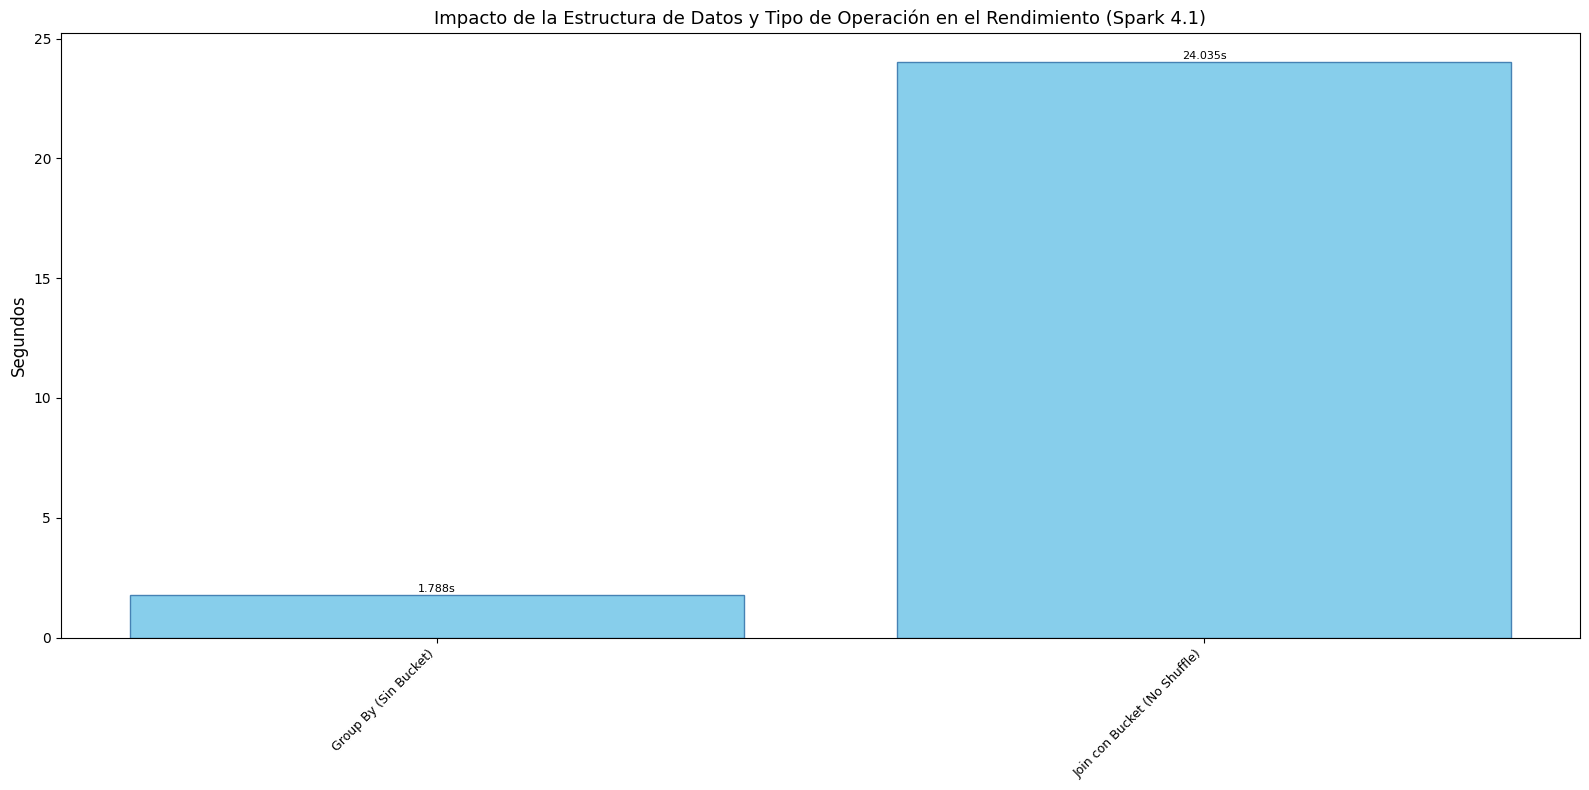


=== Tabla resumen de tiempos ===
                   Escenario    Tiempo
       Group By (Sin Bucket)  1.787674
Join con Bucket (No Shuffle) 24.035486


In [26]:
df_plot = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(range(len(df_plot)), df_plot['Tiempo'], color='skyblue', edgecolor='steelblue')
ax.set_ylabel('Segundos', fontsize=12)
ax.set_title('Impacto de la Estructura de Datos y Tipo de Operación en el Rendimiento (Spark 4.1)', fontsize=13)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['Escenario'], rotation=45, ha='right', fontsize=9)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}s', 
            va='bottom', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== Tabla resumen de tiempos ===")
print(df_plot.to_string(index=False))

In [32]:
spark.stop()